<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Домашнее задание 2. Линейная регрессия.</span></h2>

<div style="box-sizing:border-box;max-width:100%;margin:18px 0 26px;padding:18px 20px;border:1px solid rgba(127, 127, 127, 0.28);border-left:4px solid #F13A3F;border-radius:12px;background:rgba(127, 127, 127, 0.07);color:inherit;">
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Общие правила</div>
  <ul style="margin:10px 0 0;padding-left:22px;line-height:1.55;">
    <li>Выполненную работу <strong>в формате <code>ipynb</code></strong> нужно отправить в кабинете студента <a href="https://thetahat.ru/"><strong>на сайте ThetaHat</strong></a>. Инструкция по регистрации на сайте, записи на курс и сдаче домашек есть на странице курса в ЛМС. <strong>Работы, присланные иным способом, не принимаются.</strong> Дедлайны указаны в личном кабинете, они являются строгими.</li>
    <li>Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><strong>руководство по оформлению ДЗ</strong></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.</li>
    <li>Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><strong>правила использования ИИ-инструментов</strong></a> при решении домашнего задания.</li>
    <li>Выполнять задание необходимо полностью самостоятельно. <strong>При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф согласно правилам на странице курса.</strong></li>
    <li>Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/thetagrader"><img src="https://thetahat.ru/images/ai_eval_small.png" style="display:inline;vertical-align:middle;" alt="ThetaGrader"></a> <a href="https://thetahat.ru/thetagrader"><strong>ThetaGrader</strong></a>. Результаты проверки будут отправлены вам в течение 1-2 суток после дедлайна. После вы можете исправить ошибки или аргументировать свое мнение и отправить на проверку проверяющему. Подробнее на странице курса в ЛМС.</li>
    <li>Никакой код из данного задания при проверке запускаться не будет. <em>Если код не выполнен, недописан и т.д., то он не оценивается.</em></li>
  </ul>
  </br>
    
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Правила заполнения ноутбука</div>
  <ul style="margin:8px 0 0;padding-left:22px;line-height:1.55;">
    <li>Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.</li>
    <li>Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены <code>&lt;...&gt;</code>.</li>
    <li>Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках. Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.</li>
    <li>В markdown-ячейках, содержащих описание задачи, находятся специальные отметки, которые <strong style="color:red;">запрещается модифицировать</strong>.</li>
    <li>Решение теоретических задач оформляйте в markdown-ячейках в формате $\LaTeX$. При решении можно использовать ИИ-инструменты для оформления написанного самостоятельно решения, например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.</li>
    <li>При нарушении данных правил работа может получить 0 баллов.</li>
  </ul>
</div>

## 🔵 <font color="blue">Часть L</font>

Дедлайн по части M во вторник 29.09 в 16:00. Дедлайн по этой части **в субботу 03.10 в 23:59**. Подробнее в описании курса в ЛМС.


**Баллы эту часть задания:**

* Задача 2 &mdash; 30 баллов;
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 40 баллов.

In [110]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid", palette="Set2")

In [ ]:
# Bot check

# HW_ID: ysda_ml1_task2
# Система проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так система проверит, что ты ничего не перепутал, и отправляешь финальную версию,
# а не промежуточную. После отправки работы со статусом final до дедлайна все 
# еще можно вносить исправления и отправлять повторно.

# Никакие значения в этой ячейке не влияют на факт сдачи работы.

---

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 2</span>


*Теперь давайте углубимся в теорию градиентных методов оптимизации. Эти подходы будут часто встречаться, поэтому важно освоить их применение. Для этого применим градиентные методы в другом методе обучения линейной регрессии.*

*В этой задаче ожидается теоретическое решение, реализация метода не предполагается.*

Рассмотрим линейную регрессию $y(x) = x^T \theta$, причем для оценки $\theta$ будем рассматривать функцию потерь Хьюбера
$$R(x) = \frac{x^2}{2} I\{|x| \leqslant c\} + c\left(|x| - \frac{c}{2}\right)I\{|x| > c\}.$$

Тем самым задача оптимизации имеет вид
$$\sum_{i=1}^n R(Y_i - x_i^T \theta) \longrightarrow \min_{\theta \in \mathbb{R}^d}.$$

**1.** Нарисуйте график $R(x)$. В чем польза выбора такой функции потерь?

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

1. Подумайте, что происходит в случае больших отклонений предсказаний от истины? Что это за точки?
    
2. Обратите внимание на поведение $R(x)$ в точке $x=c$.
</details>

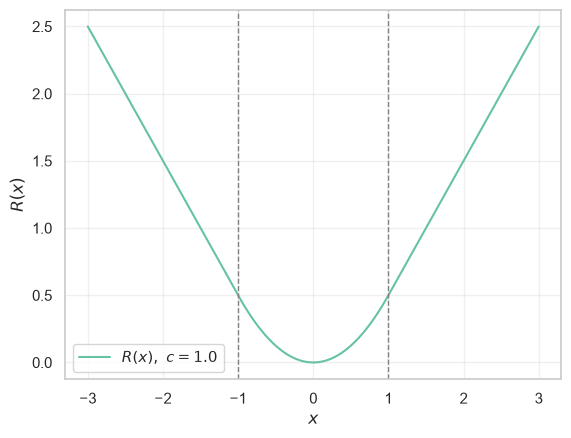

In [98]:
c = 1.0
x = np.linspace(-3, 3, 1_000)

R = np.where(
    np.abs(x) <= c,
    x**2 / 2,
    c * (np.abs(x) - c / 2),
)

plt.plot(x, R, label=rf"$R(x),\ c={c}$")
plt.axvline(-c, color="gray", linestyle="--", linewidth=1)
plt.axvline(c, color="gray", linestyle="--", linewidth=1)
plt.xlabel("$x$")
plt.ylabel("$R(x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

1. Для больших отклонений функция ведет себя линейно. Это позволяет не переобучать модель на выбросах в данных (как в случае с квадратичной функцией).
2. Для малых x функция ведет себя квадратично, типичный выбор для евклидовых пространств.
3. Функция также имеет непрерывную первую производную.

**2.** Выпишите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

Производная $R'(x) = x \cdot I\{\lvert x \rvert \leq c\}
+ c \cdot \operatorname{sgn}(x) \cdot I\{\lvert x \rvert > c\}$.

Это можно переписать как

$$
R'(x) =
\begin{cases}
x, & \text{если } \lvert x \rvert \leq c, \\
c \cdot \operatorname{sgn}(x), & \text{если } \lvert x \rvert > c.
\end{cases}
$$

Рассмотрим среднюю функцию потерь

$$
L(\theta) = \frac{1}{n} \sum_{i=1}^n R(Y_i - x_i^\top\theta).
$$

В первом случае она совпадает с квадратичной функцией потерь. Из лекции градиент в таком случае равен
$\frac{1}{n}X^\top(X\theta - Y)$.

Во втором случае производная на границе $c$ совпадает с MSE и далее «обрезается», то есть можно переписать как
$R'(r) = \min\bigl(c, \max(-c, r)\bigr) = \operatorname{clip}(r, -c, c)$.

Тогда, обобщая, градиент равен

$$
\nabla_\theta L(\theta)
= -\frac{1}{n} X^\top \operatorname{clip}(Y - X\theta, -c, c).
$$

Шаг градиентного спуска:

$$
\theta_{t+1}
= \theta_t + \frac{\eta}{n} X^\top \operatorname{clip}(Y - X\theta_t, -c, c).
$$

Для стохастического градиентного спуска выберем мини-батч
$I = \{i_1, \ldots, i_k\}$.
Тогда шаг имеет вид:

$$
\theta_{t+1}
= \theta_t + \frac{\eta}{k} X_I^\top
\operatorname{clip}(Y_I - X_I\theta_t, -c, c).
$$

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 3</span>


*Как говорилось на лекции, в стохастическом градиентном спуске (SGD) важно использовать несмещенные оценки градиента. Давайте посмотрим, как ведет себя SGD, если использовать смещенные оценки.*

Пусть случайная величина $X$ имеет нормальное распределение с параметрами $(a, \sigma^2)$, то есть:
$$
X \sim \mathcal{N}(a, \sigma^2)
$$
Рассмотрим следующую задачу оптимизации:
$$
f(a, \sigma) = (\mathsf{E}X-1)^2 + (\mathsf{D}X - 1)^2 \longrightarrow \min_{a, \sigma}
$$
В данном случае правильный ответ мы можем легко найти непосредственно, однако в реальности возникают гораздо более сложные функции, и решить задачу напрямую руками не представляется возможным. Для решения таких задач применяются различные градиентные методы, такие как, например, стохастический градиентный спуск. Оказывается, что в нём критически важно использовать несмещенные оценки градиента.

*Замечание.* Если смещение заключается только в том, что математическое ожидание оценки отличается от вектора градиента домножением каждой компоненты на одну и ту же константу, то проблем нет &mdash; все равно мы используем шаг градиента.

В данной задаче вам предлагается на примере простой функции убедиться, насколько важным оказывается использовать несмещенные оценки в итерационных процедурах.

**Решение:**

Запишите оптимальные значения параметров $a$ и $\sigma^2$, а также шаг простого градиентного спуска (не стохастического) для минимизации определенной выше функции $f(a, \sigma)$ по параметрам $a$ и $\sigma$:

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>
Просто вырази функцию $f$ через $a$ и $\sigma$ и запиши шаг градиентного спуска для этих параметров.
</details>

Из формулы оптимальные значения $a = 1$, $\sigma^2 = 1$

Саму формулу можно переписать как $f(a, \sigma) = (a - 1)^2 + (\sigma^2 - 1)^2$.  

Откуда градиент
$$
\nabla f(a, \sigma) =
\begin{pmatrix}
2(a - 1) \\
4\sigma(\sigma^2 - 1)
\end{pmatrix}.
$$

Тогда шаг градиентного спуска равен

$$
\begin{pmatrix}
a_{t+1} \\
\sigma_{t+1}
\end{pmatrix}
=
\begin{pmatrix}
a_t \\
\sigma_t
\end{pmatrix}
- \eta
\begin{pmatrix}
2(a_t - 1) \\
4\sigma_t(\sigma_t^2 - 1)
\end{pmatrix}.
$$

Реализуйте метод простого градиентного спуска для выше описанной задачи оптимизации, выбрав некоторое начальное приближение параметров. Для каждой итерации сохраните текущие значения среднего и дисперсии, постройте график зависимости значений $a$ и $\sigma^2$ от шага процедуры. Наблюдается ли сходимость к оптимальным параметрам?

In [62]:
def f(a, s):
    return (a - 1)**2 + (s**2 - 1)**2

a_start = 10
s_start = 3

a = a_start
s = s_start
eps = 10**(-7)
eta = 10**(-2)
diff = 1
A = [a]
S = [s]

while diff > eps:
    a-= eta * 2 * (a - 1)
    s-= eta * 5 * s * (s * s - 1)
    A.append(a)
    S.append(s)
    diff = abs(f(A[-1], S[-1]) - f(A[-2], S[-2]))

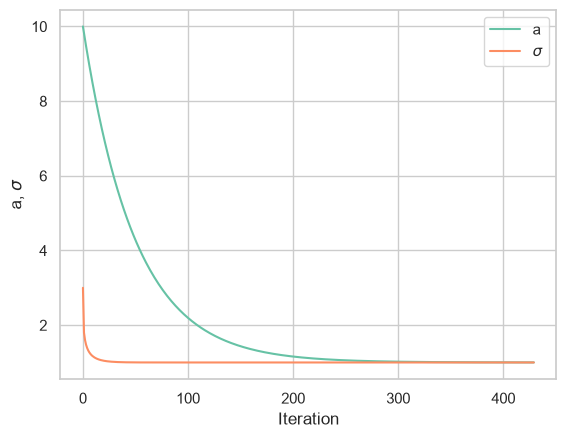

In [63]:
plt.plot(A, label="a")
plt.plot(S, label="$\\sigma$")
plt.xlabel("Iteration")
plt.ylabel("a, $\\sigma$")
plt.legend()
plt.grid(True)
plt.show()

Для определенных стартовых значений сходимость присутствует.

Теперь предположим, что мы хотим оценить градиент стохастически. Например, давайте текущие значения среднего и дисперсии оценивать изученным ранее методом Монте-Карло. А именно, каждый раз мы будем генерировать выборку размера 5 из нормального распределения с текущими значениями параметров и далее по ней оценивать градиент.
Для оценки математического ожидания ипользуйте несмещенную оценку 
$$\widehat{a} = \overline{X} := \frac{1}{n}\sum_{i=1}^n X_i,$$
а для дисперсии &mdash; смещенную 
$$\widehat{\sigma}^2 = S^2 := \frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2.$$

Реализуйте описанный выше подход. Как и прежде, изобразите текущие значения параметров в зависимости от итерации. Сошлась ли такая процедура к оптимальным значениям?

In [60]:
def f(a, s):
    return (a - 1)**2 + (s**2 - 1)**2

from math import sqrt
a_start = 3
s_start = 3

a = a_start
s = s_start
eps = 10**(-7)
eta = 10**(-3)
diff = 1
A = [a]
S = [s]
maxiter = 2000

while diff > eps and len(A) < maxiter:
    sample = np.random.normal(loc=a, scale=s, size=5)
    a_est = np.mean(sample)
    var_est = np.var(sample, ddof=0)
    a-= eta * 2 * (a_est - 1)
    s-= eta * 4 * s * (var_est - 1)
    A.append(a)
    S.append(s)
    diff = abs(f(A[-1], S[-1]) - f(A[-2], S[-2]))

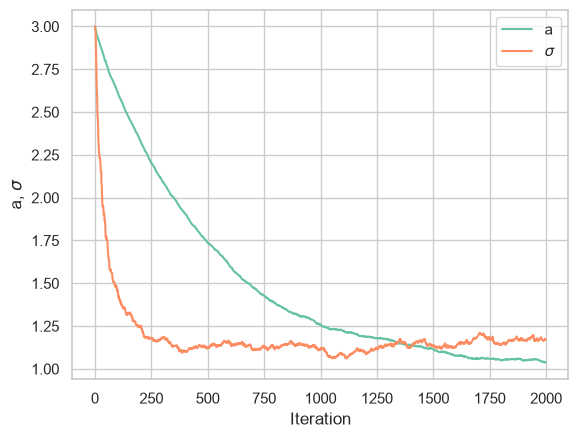

In [61]:
plt.plot(A, label="a")
plt.plot(S, label="$\\sigma$")
plt.xlabel("Iteration")
plt.ylabel("a, $\\sigma$")
plt.legend()
plt.grid(True)
plt.show()

Ну в целом параметры неплохо сходятся, но дисперсия сходится не туда.

Теперь изменим нашу процедуру, взяв несмещенную оценку для дисперсии
$$\widehat{\sigma}^2 = S^2_{u} := \frac{1}{n-1}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2.$$

Обратите внимание на параметр `ddof` в функции `np.var`.

Поменялся ли результат?

In [58]:
a_start = 3
s_start = 3

a = a_start
s = s_start
eta = 10**(-3)
diff = 1
A = [a]
S = [s]
maxiter = 2000

while len(A) < maxiter:
    sample = np.random.normal(loc=a, scale=s, size=5)
    a_est = np.mean(sample)
    var_est = np.var(sample, ddof=1)
    a-= eta * 2 * (a_est - 1)
    s-= eta * 4 * s * (var_est - 1)
    A.append(a)
    S.append(s)

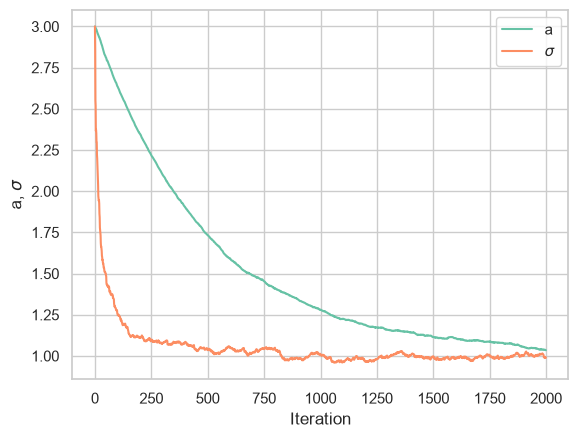

In [59]:
plt.plot(A, label="a")
plt.plot(S, label="$\\sigma$")
plt.xlabel("Iteration")
plt.ylabel("a, $\\sigma$")
plt.legend()
plt.grid(True)
plt.show()

**Вывод:**

Cмещенная оценка сходится не к той точке, в отличие от несмещенной. Получается что и правда важно использовать несмещенные оценки!

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 4</span>


*Наконец, рассмотрим, как можно использовать стохастические градиентные методы при оптимизации сложных функций.*

Некоторая ML-модель имеет один параметр $\theta$, который обучается посредством *оптимизации* функции
$$\mathcal{L}(\theta) = \mathsf{E} \exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right),$$
где $\xi$ имеет стандартное нормальное распределение, а $\eta$ &mdash; пуассоновское распределение с параметром 5 и не зависит от $\xi$.


Оптимизируйте эту функцию, используя стохастический градиентный спуск. Необходимо вывести формулы и реализовать их.

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>
Дифференцирование и мат. ожидание можно менять местами. Далее, обрати внимание на метод Монте-Карло с лекции, с его помощью можно оценить мат. ожидание.
</details>

Производная по $\theta$ равна
$$
\mathcal{L}'(\theta)
= \mathsf{E}\left[
\exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right)
\cdot \frac{2\theta\xi^2\sqrt{\eta}}{(1+\theta^2)^2}
\right].
$$

In [96]:
theta = 10
rate = 10**(0)
T = [theta]
maxiter = 800

def dL(theta, xi, eta):
    z = xi**2 * np.sqrt(eta)
    grad = (np.exp(-z / (1 + theta**2)) * 2 * theta * z / (1 + theta**2)**2)
    return np.mean(grad)


while len(T) < maxiter:
    xi_sample = np.random.normal(size=5)
    theta_sample = np.random.poisson(lam=5, size=5)
    theta -= rate * dL(theta, xi_sample, theta_sample)
    T.append(theta)

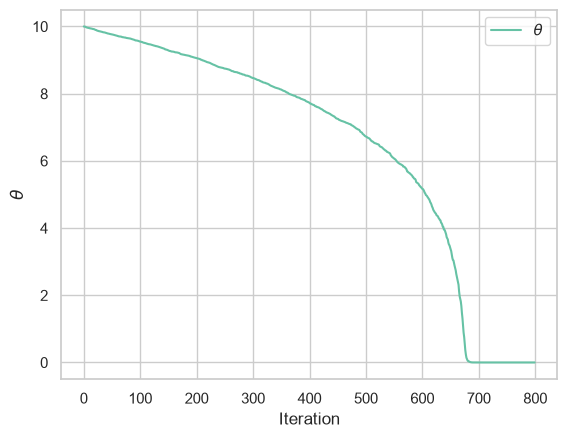

In [97]:
plt.plot(T, label="$\\theta$")
plt.xlabel("Iteration")
plt.ylabel("$\\theta$")
# plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.show()

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 5</span>


*Устали писать формулы? Самое время что-то закодить! Давайте закодим то, что вывели во 2-й задаче.*

В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Реализуйте класс. **При реализации класса запрещено пользоваться ИИ-инструментами.**

In [126]:
# При реализации класса запрещено пользоваться ИИ-инструментами.

from sklearn.base import BaseEstimator

class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000) -> None:
        """Инициализирует модель.

        Параметры:
        c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак.
        max_iter (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter
        self.tol = 10**-3
        self.tol_window = 100
        self.rate = 10**-2
        self.k = 128

    def loss(self, residuals) -> float:
        losses = np.where(
            np.abs(residuals) <= self.c,
            residuals**2 / 2,
            self.c * (np.abs(residuals) - self.c / 2),
        )
    
        return np.mean(losses)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.
        """
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")

        if self.fit_intercept:
            X = np.column_stack([np.ones(X.shape[0]), X])

        k = min(self.k, X.shape[0])
        losses = []
        theta = np.zeros(X.shape[1])
        
        for i in range(self.max_iter):    
            I = np.random.choice(X.shape[0], size=k, replace=False)
            X_I = X[I]
            Y_I = y[I]

            residuals = Y_I - X_I @ theta
            clipped = np.clip(residuals, -self.c, self.c)
            grad = X_I.T @ clipped / k
            theta += self.rate * grad
            losses.append(self.loss(residuals))

            win = self.tol_window
            if i > 2 * self.tol_window:
                prev = np.mean(losses[-2 * win:-win])
                curr = np.mean(losses[-win:])
                if (np.abs(1 - curr / prev) < self.tol):
                    break

        self.intercept_ = 0
        if self.fit_intercept:
            self.intercept_ = theta[0]
            theta = theta[1:]
            
        self.coef_ = theta  # Коэффициенты модели
        self.n_iter_ = i + 1 # Число итераций

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """

        if X.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        return X @ self.coef_ + self.intercept_

**2.** Загрузите данные из файлов <a href="https://thetahat.ru/files/ad/main/3/train.csv"><code>train.csv</code></a>, <a href="https://thetahat.ru/files/ad/main/3/test.csv"><code>test.csv</code></a>. Не забудьте, что всю аналитику, а также процесс обучения и подбор гиперпараметров необходимо выполнять на обучающей выборке.

In [100]:
train = pd.read_csv("https://thetahat.ru/files/ad/main/3/train.csv")
test = pd.read_csv("https://thetahat.ru/files/ad/main/3/test.csv")

In [101]:
train

,feature_1,feature_2,feature_3,target
0,2.320800,-1.098571,0.117091,162.910894
1,0.625119,-0.782367,-0.813596,21.113006
2,-0.807648,-0.185054,-1.446535,-36.128990
3,-0.291837,-1.616474,-0.761492,-56.474495
4,0.938747,0.087531,0.607112,189.589573
...,...,...,...,...
330,-3.265200,-3.672560,-2.657417,708.438847
331,-3.853111,-3.152533,-3.493896,744.066873
332,-2.852711,-3.301565,-3.636479,707.650768
333,-3.060254,-2.831997,-3.012904,720.185363


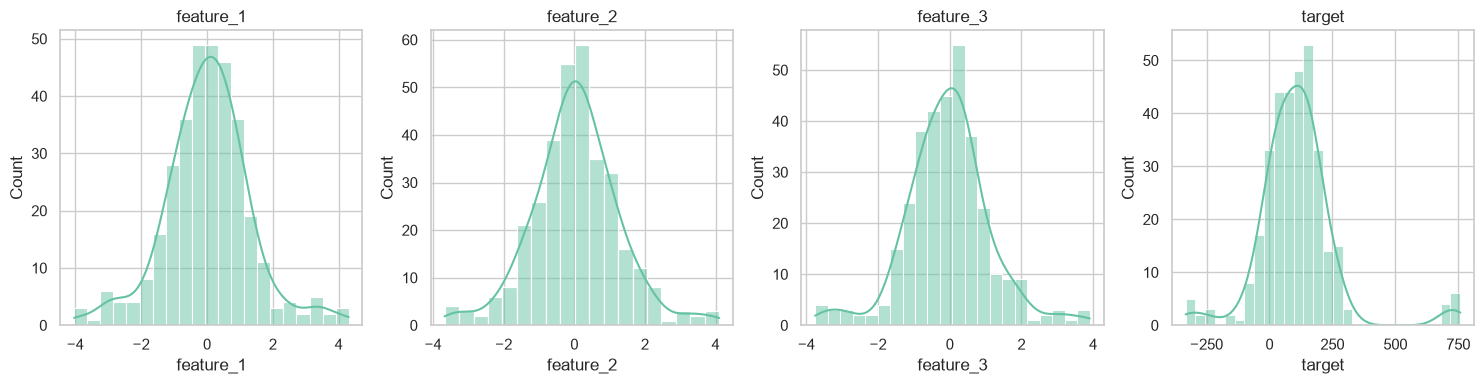

In [102]:
features = ["feature_1", "feature_2", "feature_3", "target"]
cols = len(features)

fig, axes = plt.subplots(1, cols, figsize=(15, 4), squeeze=False)

for feature, ax in zip(features, axes.flat):
    sns.histplot(train[feature], kde=True, ax=ax)
    ax.set_title(feature)

for ax in axes.flat[len(features):]:
    ax.remove()

plt.tight_layout()
plt.show()

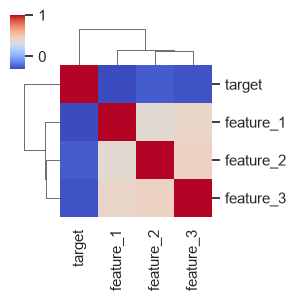

In [105]:
sns.clustermap(train.corr(numeric_only=True), cmap="coolwarm", annot=False, figsize=(3, 3))
plt.show()

Посмотрите на зависимость целевой переменной от каждого признака.

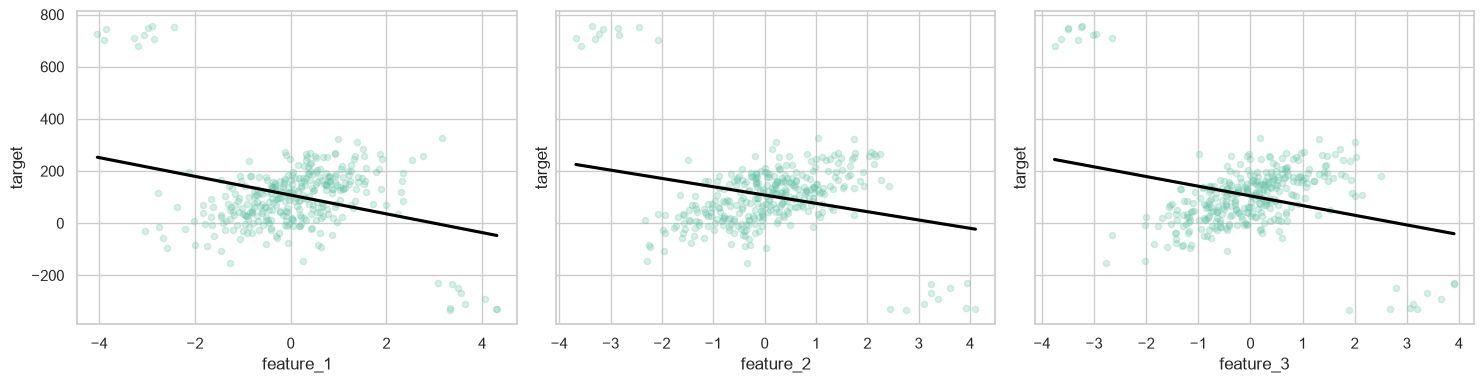

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, column in zip(axes, ["feature_1", "feature_2", "feature_3"]):
    sns.regplot(
        data=train,
        x=column,
        y="target",
        scatter_kws={"alpha": 0.25, "s": 20},
        line_kws={"color": "black"},
        ci=None,
        ax=ax,
    )

fig.tight_layout()

Что можно сказать о наличии возможных выбросов? Какое влияние они могут оказать? 

Кажется что target положительно зависит от каждого признака, но выбросы искривляют эту зависимость в противоположную сторону.
Линейная регрессия по этим признакам без изменений не может отдельно обработать основные значения и значения близкие с краям, поэтому такие выбросы будут негативно сказываться на качестве, особенно с MSE, т.к. там они будут иметь квадратичное влияние.

**3.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике [MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

In [190]:
model = LinearRegression()
x_cols = train.columns.drop("target").tolist()
model.fit(train[x_cols], train["target"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-23.47,-14.02,-19.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['feature_1','feature_2','feature_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,106.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [191]:
train_preds= model.predict(train[x_cols])
test_preds = model.predict(test[x_cols])
print("train MSE", metrics.mean_squared_error(train["target"], train_preds) ** 0.5)
print("test MSE", metrics.mean_squared_error(test["target"], test_preds) ** 0.5)
print("Target mean", np.mean(np.abs(train["target"])))

train MSE 143.87999563050988
test MSE 130.48297440711926
Target mean 134.88164968587617


Что можно сказать о качестве нашей модели?

Качество очень плохое. Ошибка больше чем среднее значение модуля таргета. 

**4.** Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [180]:
model = HuberRegression(c=200)
x_cols = train.columns.drop("target").tolist()
model.fit(train[x_cols], train["target"])

,c,200
,fit_intercept,True
,max_iter,1000
Name,Type,Value
coef_,"ndarray[float64](3,)","[ 1.13,10.02, 6.01]"
intercept_,float64,94.35
n_iter_,int,322


In [183]:
train_preds_hub = model.predict(train[x_cols])
test_preds_hub = model.predict(test[x_cols])
print("train MSE", metrics.mean_squared_error(train["target"], train_preds_hub) ** 0.5)
print("test MSE", metrics.mean_squared_error(test["target"], test_preds_hub) ** 0.5)
print("Target mean", np.mean(np.abs(train["target"])))

train MSE 161.22980879310725
test MSE 85.85241963217129
Target mean 134.88164968587617


Что изменилось?

На train ошибка особо не улучшилась, а test стал заметно лучше.

**5.** Для обучающей выборки постройте два графика (по графику на каждую модель), на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

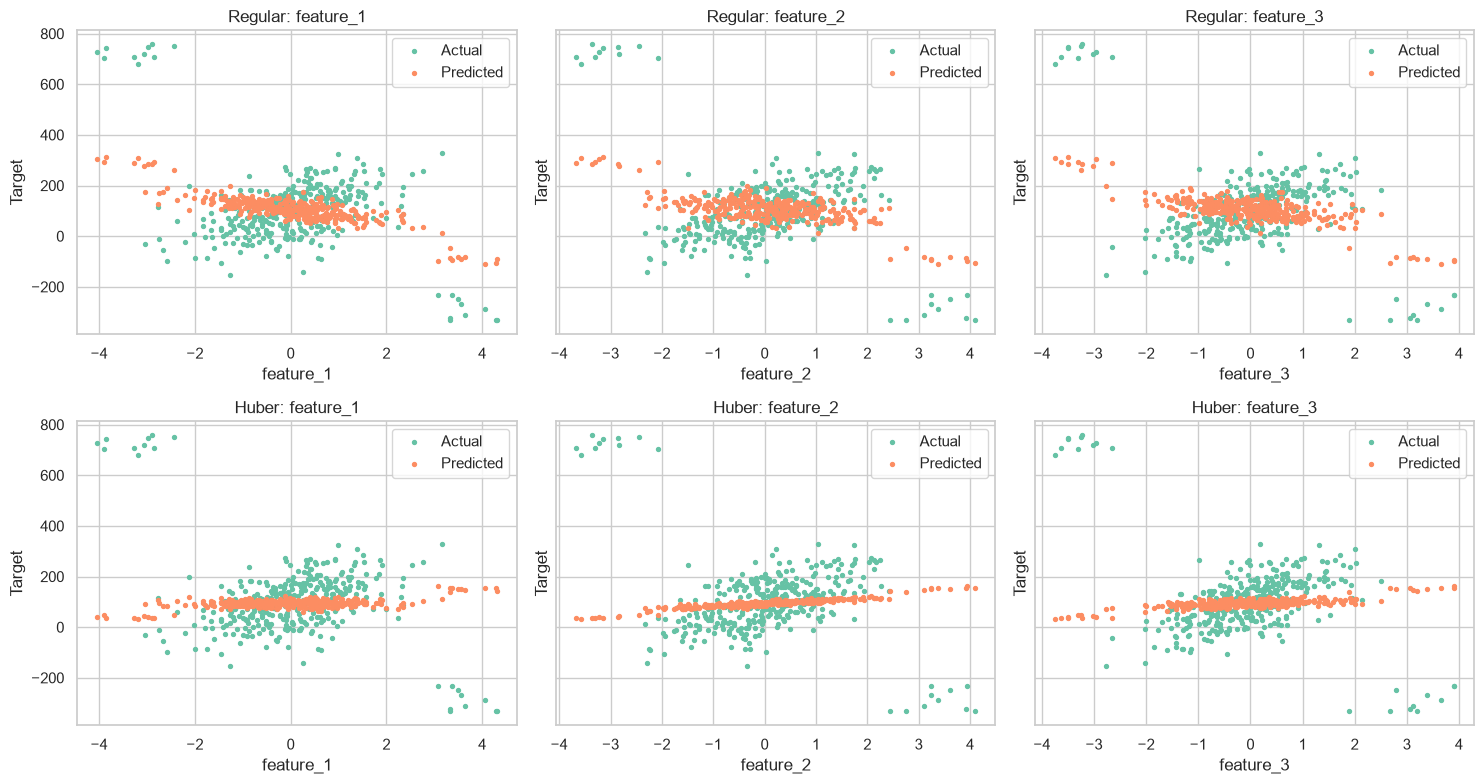

In [192]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for row, (preds, title) in enumerate([
    (train_preds, "Regular"),
    (train_preds_hub, "Huber"),
]):
    for col, feature in enumerate(["feature_1", "feature_2", "feature_3"]):
        ax = axes[row, col]

        ax.scatter(train[feature], train["target"], s=8, label="Actual")
        ax.scatter(train[feature], preds, s=8, label="Predicted")

        ax.set_title(f"{title}: {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Target")
        ax.grid(True)
        ax.legend()

fig.tight_layout()
plt.show()

Что можно заметить на этих графиках?

Обычная регрессия, как и предполагалась, пытается сильнее подстроиться под выбросы и в итоге делает обратную зависимость от фичей, а не прямую.
Регрессия с Хьюбером менее подвержена этому влиянию и правильно улавливает положительную корреляцию основной массы точек.

**Вывод:**

Функции потерь можно выбирать разные. Для улучшения качества моделей можно уплощать хвосты функции потерь на масштабах, потенциально означающих выбросные значения, чем реально большие ошибки.

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для курса ML-1 ШАД</div>